In [1]:
# -*- coding: utf-8 -*-
"""
Process A 물리 모델 분석 노트북
src/environment/process_a_env.py 구현을 직접 사용해서 분석합니다.
"""
import sys
from pathlib import Path
import contextlib
import io
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# 프로젝트 루트 경로 설정
ROOT = Path().resolve().parent
sys.path.append(str(ROOT))
(ROOT / "results").mkdir(exist_ok=True)

# 실제 env 구현에서 import
from src.environment.process_a_env import (
    ProcessA_Env,
    W1_BASE, W2_BASE, W3_BASE, B_BASE, W12_BASE,
    BETA, BETA_K, GAMMA, GAMMA_K,
    DELTA_W1, DELTA_W12, DELTA_B,
)
from src.objects import ProcessA_Machine, Task

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

print("환경 설정 완료")
print(f"  PROJECT ROOT: {ROOT}")
print(f"\n[물리 모델 상수 — process_a_env.py 모듈 레벨 상수]")
print(f"  선형 계수:    W1={W1_BASE}, W2={W2_BASE}, W3={W3_BASE}, B={B_BASE}")
print(f"  교호작용:     W12={W12_BASE}  (s1 × s2 비선형 항)")
print(f"  소모품 경시:  BETA={BETA}, BETA_K={BETA_K}  → effectiveness = 1 - BETA*tanh(BETA_K*u)")
print(f"  노이즈 증가:  GAMMA={GAMMA}, GAMMA_K={GAMMA_K}  → std_dev = GAMMA*tanh(GAMMA_K*u)")
print(f"  장비 노후화:  ΔW1={DELTA_W1}, ΔW12={DELTA_W12}, ΔB={DELTA_B}  (m_age 선형 감소)")

환경 설정 완료
  PROJECT ROOT: E:\batch_scheduling

[물리 모델 상수 — process_a_env.py 모듈 레벨 상수]
  선형 계수:    W1=0.5, W2=0.3, W3=0.2, B=45.0
  교호작용:     W12=0.01  (s1 × s2 비선형 항)
  소모품 경시:  BETA=0.2, BETA_K=0.1  → effectiveness = 1 - BETA*tanh(BETA_K*u)
  노이즈 증가:  GAMMA=1.5, GAMMA_K=0.1  → std_dev = GAMMA*tanh(GAMMA_K*u)
  장비 노후화:  ΔW1=0.001, ΔW12=0.0001, ΔB=0.02  (m_age 선형 감소)


In [2]:
# =============================================================
# 헬퍼 함수 — ProcessA_Env 기반 분석 유틸리티
# =============================================================

def make_machine(m_age=0, u=0.0, batch_size=1):
    """지정된 상태를 가진 ProcessA_Machine 생성."""
    m = ProcessA_Machine(0, batch_size=batch_size)
    m.m_age = m_age
    m.u = float(u)
    return m

def make_task(spec_a=(45.0, 55.0), uid=0):
    """QA 체크용 Task 생성."""
    return Task(uid=uid, job_id="test", due_date=100,
                spec_a=spec_a, spec_b=(60.0, 90.0), arrival_time=0)

def get_mean_qa(env_det, machine, recipe):
    """
    Deterministic 모드 env에서 _run_qa_check를 호출해 평균 품질값 반환.
    stochastic 없이 g_s * effectiveness 그대로.
    """
    task = make_task(uid=0)
    with contextlib.redirect_stdout(io.StringIO()):
        env_det._run_qa_check(machine, recipe, task, current_time=0)
    return task.history[-1]['qa'] if task.history else float('nan')

def sample_qa(env_stoch, machine, recipe, n=300):
    """
    Stochastic 모드 env에서 _run_qa_check를 n번 호출해 품질 분포 샘플링.
    print 출력 억제. 매번 새 Task 생성으로 history 간섭 방지.
    """
    samples = []
    suppress = io.StringIO()
    for i in range(n):
        task = make_task(uid=i)
        with contextlib.redirect_stdout(suppress):
            env_stoch._run_qa_check(machine, recipe, task, current_time=0)
        if task.history:
            samples.append(task.history[-1]['qa'])
    return np.array(samples)

# 실험용 env (stochastic / deterministic)
env_stoch = ProcessA_Env({"deterministic_mode": False, "num_machines_A": 1})
env_det   = ProcessA_Env({"deterministic_mode": True,  "num_machines_A": 1})

# 기본 실험 설정
SPEC_A       = (45.0, 55.0)
DEFAULT_RECIPE = [10.0, 2.0, 1.0]

print("헬퍼 함수 준비 완료")
print(f"  기본 레시피: s1={DEFAULT_RECIPE[0]}, s2={DEFAULT_RECIPE[1]}, s3={DEFAULT_RECIPE[2]}")
print(f"  Task Spec A: {SPEC_A[0]:.1f} ≤ QA ≤ {SPEC_A[1]:.1f}")

# 빠른 검증: 기본 조건에서 QA 계산 확인
m_sample = make_machine(m_age=0, u=0.0)
qa_sample = get_mean_qa(env_det, m_sample, DEFAULT_RECIPE)
print(f"\n  [검증] m_age=0, u=0, recipe={DEFAULT_RECIPE} → QA={qa_sample:.2f}")

헬퍼 함수 준비 완료
  기본 레시피: s1=10.0, s2=2.0, s3=1.0
  Task Spec A: 45.0 ≤ QA ≤ 55.0

  [검증] m_age=0, u=0, recipe=[10.0, 2.0, 1.0] → QA=51.00


=== 장비 나이(m_age)에 따른 물리 모델 파라미터 변화 ===
  공식: w1 = W1_BASE*(1 - DELTA_W1*m_age)
        w12 = W12_BASE*(1 - DELTA_W12*m_age)
        b   = B_BASE - DELTA_B*m_age

   m_age |       w1 |        w12 |        b |  mean_qa (u=0, default recipe)
----------------------------------------------------------------------
       0 |   0.5000 |   0.010000 |    45.00 |                          51.00
      50 |   0.4750 |   0.009950 |    44.00 |                          49.75
     100 |   0.4500 |   0.009900 |    43.00 |                          48.50
     200 |   0.4000 |   0.009800 |    41.00 |                          46.00
     300 |   0.3500 |   0.009700 |    39.00 |                          43.49

→ m_age 증가 시: w1↓, w12↓, b↓ — 장비 노후화로 공정 효율 전반 저하


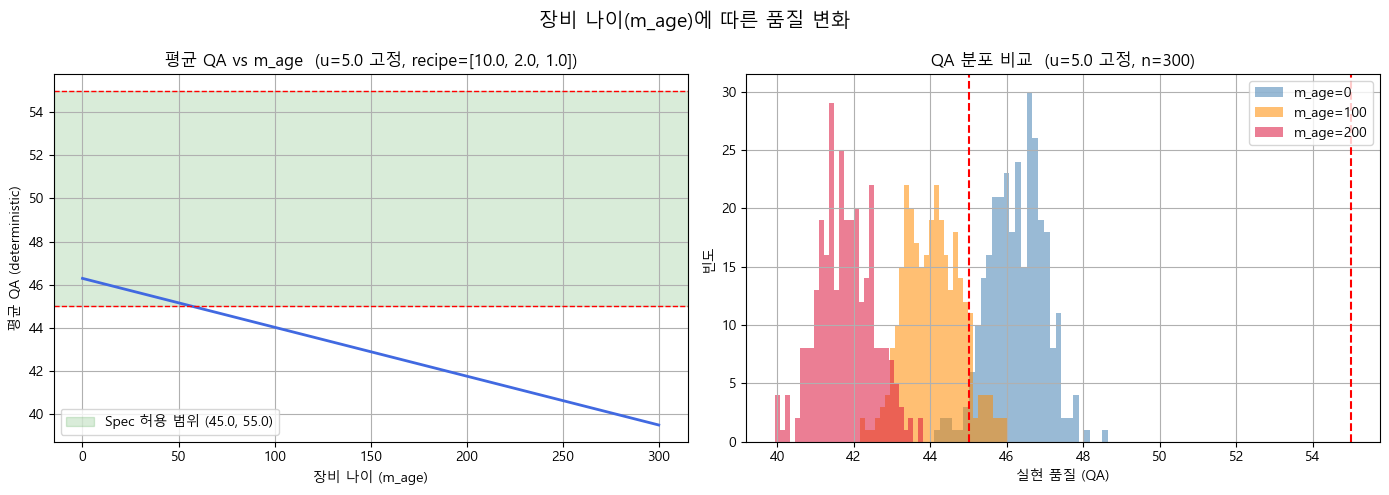

저장: results/p_a_01_machine_age_effect.png


In [3]:
# =============================================================
# 1. 장비 나이(m_age)에 따른 물리 모델 파라미터 변화 확인
#    _get_physical_model_params() 직접 호출
# =============================================================

print("=== 장비 나이(m_age)에 따른 물리 모델 파라미터 변화 ===")
print(f"  공식: w1 = W1_BASE*(1 - DELTA_W1*m_age)")
print(f"        w12 = W12_BASE*(1 - DELTA_W12*m_age)")
print(f"        b   = B_BASE - DELTA_B*m_age\n")
print(f"{'m_age':>8} | {'w1':>8} | {'w12':>10} | {'b':>8} | {'mean_qa (u=0, default recipe)':>30}")
print("-" * 70)

for m_age in [0, 50, 100, 200, 300]:
    machine = make_machine(m_age=m_age, u=0.0)
    w1, w12, b = env_det._get_physical_model_params(m_age)
    qa = get_mean_qa(env_det, machine, DEFAULT_RECIPE)
    print(f"{m_age:>8} | {w1:>8.4f} | {w12:>10.6f} | {b:>8.2f} | {qa:>30.2f}")

print("\n→ m_age 증가 시: w1↓, w12↓, b↓ — 장비 노후화로 공정 효율 전반 저하")

# 시각화: 장비 나이에 따른 평균 QA 추이 + 분포 변화
U_FIXED = 5.0
m_age_range = np.arange(0, 301, 5)
mean_qas_age = [get_mean_qa(env_det, make_machine(m_age=int(a), u=U_FIXED), DEFAULT_RECIPE)
                for a in m_age_range]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('장비 나이(m_age)에 따른 품질 변화', fontsize=14)

# (a) 평균 QA vs m_age
ax = axes[0]
ax.plot(m_age_range, mean_qas_age, color='royalblue', linewidth=2)
ax.axhspan(SPEC_A[0], SPEC_A[1], alpha=0.15, color='green', label=f'Spec 허용 범위 {SPEC_A}')
ax.axhline(SPEC_A[0], color='red', linestyle='--', linewidth=1)
ax.axhline(SPEC_A[1], color='red', linestyle='--', linewidth=1)
ax.set_xlabel('장비 나이 (m_age)')
ax.set_ylabel('평균 QA (deterministic)')
ax.set_title(f'평균 QA vs m_age  (u={U_FIXED} 고정, recipe={DEFAULT_RECIPE})')
ax.legend()
ax.grid(True)

# (b) 각 m_age에서 품질 분포 (stochastic)
for m_age, color in [(0, 'steelblue'), (100, 'darkorange'), (200, 'crimson')]:
    machine = make_machine(m_age=m_age, u=U_FIXED)
    samples = sample_qa(env_stoch, machine, DEFAULT_RECIPE, n=300)
    axes[1].hist(samples, bins=30, alpha=0.55, color=color, label=f'm_age={m_age}')

axes[1].axvline(SPEC_A[0], color='red', linestyle='--', linewidth=1.5)
axes[1].axvline(SPEC_A[1], color='red', linestyle='--', linewidth=1.5)
axes[1].set_xlabel('실현 품질 (QA)')
axes[1].set_ylabel('빈도')
axes[1].set_title(f'QA 분포 비교  (u={U_FIXED} 고정, n=300)')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig(ROOT / "results" / "p_a_01_machine_age_effect.png", dpi=100, bbox_inches='tight')
plt.show()
print("저장: results/p_a_01_machine_age_effect.png")

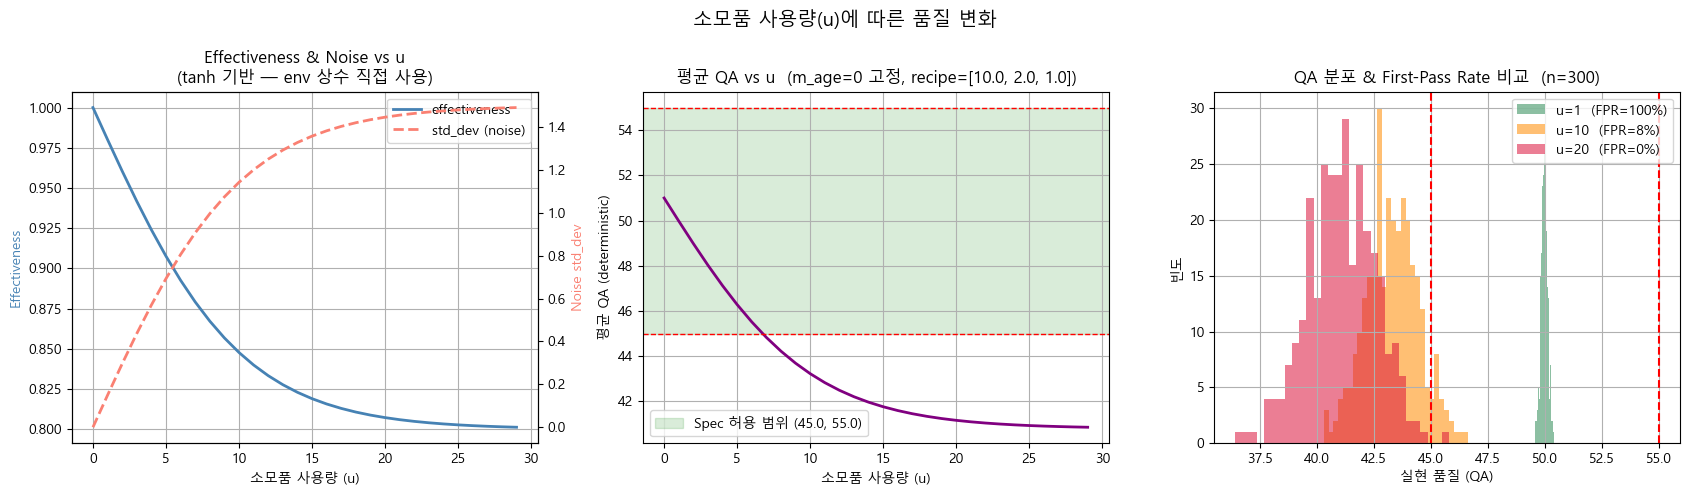

저장: results/p_a_02_consumable_effect.png

=== 소모품 사용량별 First-Pass Rate (deterministic 기준) ===
  u= 0  mean_qa=  51.00  [PASS]
  u= 5  mean_qa=  46.29  [PASS]
  u=10  mean_qa=  43.23  [FAIL]
  u=15  mean_qa=  41.77  [FAIL]
  u=20  mean_qa=  41.17  [FAIL]
  u=25  mean_qa=  40.94  [FAIL]
  u=29  mean_qa=  40.86  [FAIL]


In [4]:
# =============================================================
# 2. 소모품 사용량(u)에 따른 품질 변화
#    effectiveness = 1 - BETA * tanh(BETA_K * u)
#    std_dev       = GAMMA * tanh(GAMMA_K * u)
# =============================================================

M_AGE_FIXED = 0
u_range = np.arange(0, 30, 1)

# 이론 곡선 (env 상수 사용)
effectiveness_vals = 1 - BETA * np.tanh(BETA_K * u_range)
noise_vals         = GAMMA * np.tanh(GAMMA_K * u_range)
mean_qas_u = [get_mean_qa(env_det, make_machine(m_age=M_AGE_FIXED, u=float(u)), DEFAULT_RECIPE)
              for u in u_range]

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('소모품 사용량(u)에 따른 품질 변화', fontsize=14)

# (a) effectiveness & noise 이론 곡선
ax = axes[0]
ax2 = ax.twinx()
ax.plot(u_range, effectiveness_vals, color='steelblue', linewidth=2, label='effectiveness')
ax2.plot(u_range, noise_vals, color='salmon', linewidth=2, linestyle='--', label='std_dev (noise)')
ax.set_xlabel('소모품 사용량 (u)')
ax.set_ylabel('Effectiveness', color='steelblue')
ax2.set_ylabel('Noise std_dev', color='salmon')
ax.set_title('Effectiveness & Noise vs u\n(tanh 기반 — env 상수 직접 사용)')
ax.grid(True)
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

# (b) 평균 QA vs u
ax = axes[1]
ax.plot(u_range, mean_qas_u, color='purple', linewidth=2)
ax.axhspan(SPEC_A[0], SPEC_A[1], alpha=0.15, color='green', label=f'Spec 허용 범위 {SPEC_A}')
ax.axhline(SPEC_A[0], color='red', linestyle='--', linewidth=1)
ax.axhline(SPEC_A[1], color='red', linestyle='--', linewidth=1)
ax.set_xlabel('소모품 사용량 (u)')
ax.set_ylabel('평균 QA (deterministic)')
ax.set_title(f'평균 QA vs u  (m_age={M_AGE_FIXED} 고정, recipe={DEFAULT_RECIPE})')
ax.legend()
ax.grid(True)

# (c) 실제 분포 비교: u=1, 10, 20
ax = axes[2]
for u_val, color in [(1, 'seagreen'), (10, 'darkorange'), (20, 'crimson')]:
    machine = make_machine(m_age=M_AGE_FIXED, u=float(u_val))
    samples = sample_qa(env_stoch, machine, DEFAULT_RECIPE, n=300)
    fpr = np.mean((samples >= SPEC_A[0]) & (samples <= SPEC_A[1]))
    ax.hist(samples, bins=30, alpha=0.55, color=color,
            label=f'u={u_val}  (FPR={fpr:.0%})')
ax.axvline(SPEC_A[0], color='red', linestyle='--', linewidth=1.5)
ax.axvline(SPEC_A[1], color='red', linestyle='--', linewidth=1.5)
ax.set_xlabel('실현 품질 (QA)')
ax.set_ylabel('빈도')
ax.set_title('QA 분포 & First-Pass Rate 비교  (n=300)')
ax.legend()
ax.grid(True)

plt.tight_layout()
plt.savefig(ROOT / "results" / "p_a_02_consumable_effect.png", dpi=100, bbox_inches='tight')
plt.show()
print("저장: results/p_a_02_consumable_effect.png")

# 소모품 사용량별 first-pass rate 요약
print("\n=== 소모품 사용량별 First-Pass Rate (deterministic 기준) ===")
for u in [0, 5, 10, 15, 20, 25, 29]:
    qa = get_mean_qa(env_det, make_machine(m_age=M_AGE_FIXED, u=float(u)), DEFAULT_RECIPE)
    result = "PASS" if SPEC_A[0] <= qa <= SPEC_A[1] else "FAIL"
    print(f"  u={u:>2}  mean_qa={qa:>7.2f}  [{result}]")

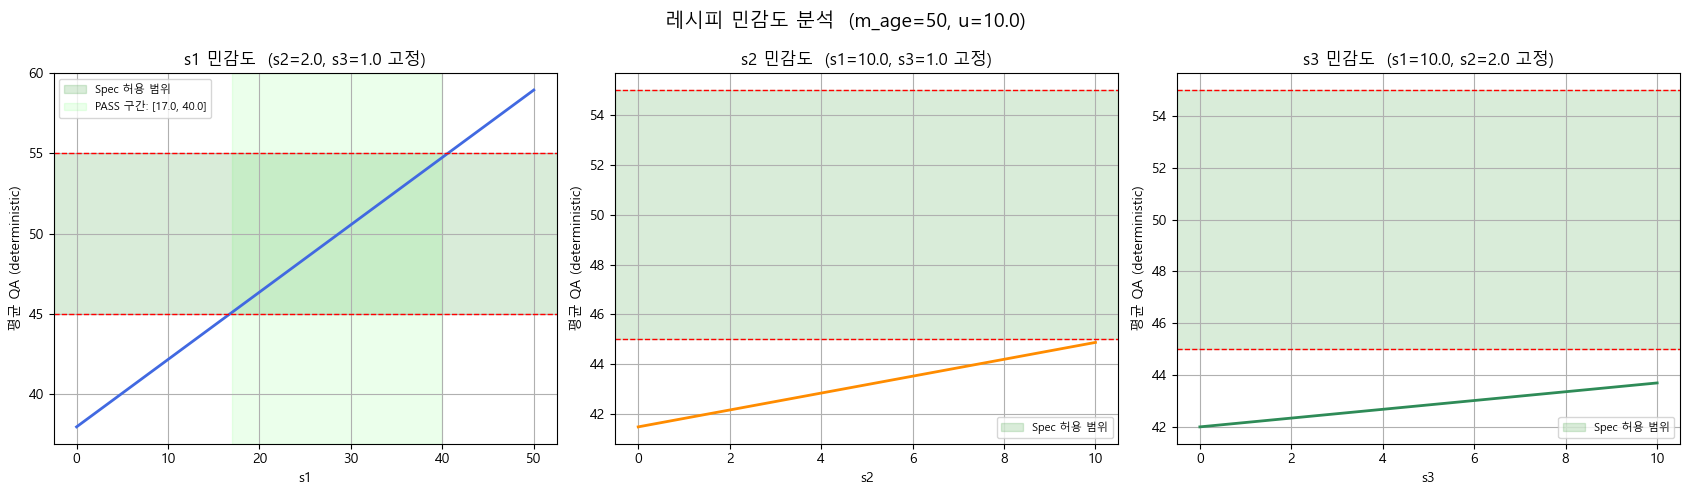

저장: results/p_a_03_recipe_sensitivity.png

=== 레시피 민감도 요약 (QA 변화 폭) ===
  s1 변화 (0→50): ΔQA = 20.98  ← 가장 큰 영향 인자
  s2 변화 (0→10): ΔQA = 3.39
  s3 변화 (0→10): ΔQA = 1.70

  → 튜너(AdaptiveTuner)가 u/m_age 상태에 따라 s1을 조정하는 것이 핵심


In [5]:
# =============================================================
# 3. 레시피 민감도 분석
#    고정 상태(m_age=50, u=10)에서 s1, s2, s3 각각 스윕
#    → 어떤 레시피 파라미터가 품질에 가장 큰 영향을 미치는가?
# =============================================================

FIXED_M_AGE = 50
FIXED_U     = 10.0
machine_fixed = make_machine(m_age=FIXED_M_AGE, u=FIXED_U)

s1_range = np.linspace(0, 50, 51)
s2_range = np.linspace(0, 10, 51)
s3_range = np.linspace(0, 10, 51)

mean_s1 = [get_mean_qa(env_det, machine_fixed, [s1, DEFAULT_RECIPE[1], DEFAULT_RECIPE[2]])
           for s1 in s1_range]
mean_s2 = [get_mean_qa(env_det, machine_fixed, [DEFAULT_RECIPE[0], s2, DEFAULT_RECIPE[2]])
           for s2 in s2_range]
mean_s3 = [get_mean_qa(env_det, machine_fixed, [DEFAULT_RECIPE[0], DEFAULT_RECIPE[1], s3])
           for s3 in s3_range]

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle(f'레시피 민감도 분석  (m_age={FIXED_M_AGE}, u={FIXED_U})', fontsize=14)

for ax, x_vals, y_vals, label, color in [
    (axes[0], s1_range, mean_s1, 's1', 'royalblue'),
    (axes[1], s2_range, mean_s2, 's2', 'darkorange'),
    (axes[2], s3_range, mean_s3, 's3', 'seagreen'),
]:
    ax.plot(x_vals, y_vals, color=color, linewidth=2)
    ax.axhspan(SPEC_A[0], SPEC_A[1], alpha=0.15, color='green', label='Spec 허용 범위')
    ax.axhline(SPEC_A[0], color='red', linestyle='--', linewidth=1)
    ax.axhline(SPEC_A[1], color='red', linestyle='--', linewidth=1)
    # spec 통과 구간 강조
    in_spec = np.array(y_vals)
    x_arr   = np.array(x_vals)
    pass_region = x_arr[(in_spec >= SPEC_A[0]) & (in_spec <= SPEC_A[1])]
    if len(pass_region) > 0:
        ax.axvspan(pass_region[0], pass_region[-1], alpha=0.08, color='lime',
                   label=f'PASS 구간: [{pass_region[0]:.1f}, {pass_region[-1]:.1f}]')
    other = [f'{k}={DEFAULT_RECIPE[i]}' for i, k in enumerate(['s1','s2','s3']) if k != label]
    ax.set_xlabel(label)
    ax.set_ylabel('평균 QA (deterministic)')
    ax.set_title(f'{label} 민감도  ({", ".join(other)} 고정)')
    ax.legend(fontsize=8)
    ax.grid(True)

plt.tight_layout()
plt.savefig(ROOT / "results" / "p_a_03_recipe_sensitivity.png", dpi=100, bbox_inches='tight')
plt.show()
print("저장: results/p_a_03_recipe_sensitivity.png")

# 민감도 요약: QA 변화량 (min → max) 비교
delta_s1 = max(mean_s1) - min(mean_s1)
delta_s2 = max(mean_s2) - min(mean_s2)
delta_s3 = max(mean_s3) - min(mean_s3)
print(f"\n=== 레시피 민감도 요약 (QA 변화 폭) ===")
print(f"  s1 변화 (0→50): ΔQA = {delta_s1:.2f}  ← 가장 큰 영향 인자")
print(f"  s2 변화 (0→10): ΔQA = {delta_s2:.2f}")
print(f"  s3 변화 (0→10): ΔQA = {delta_s3:.2f}")
print(f"\n  → 튜너(AdaptiveTuner)가 u/m_age 상태에 따라 s1을 조정하는 것이 핵심")

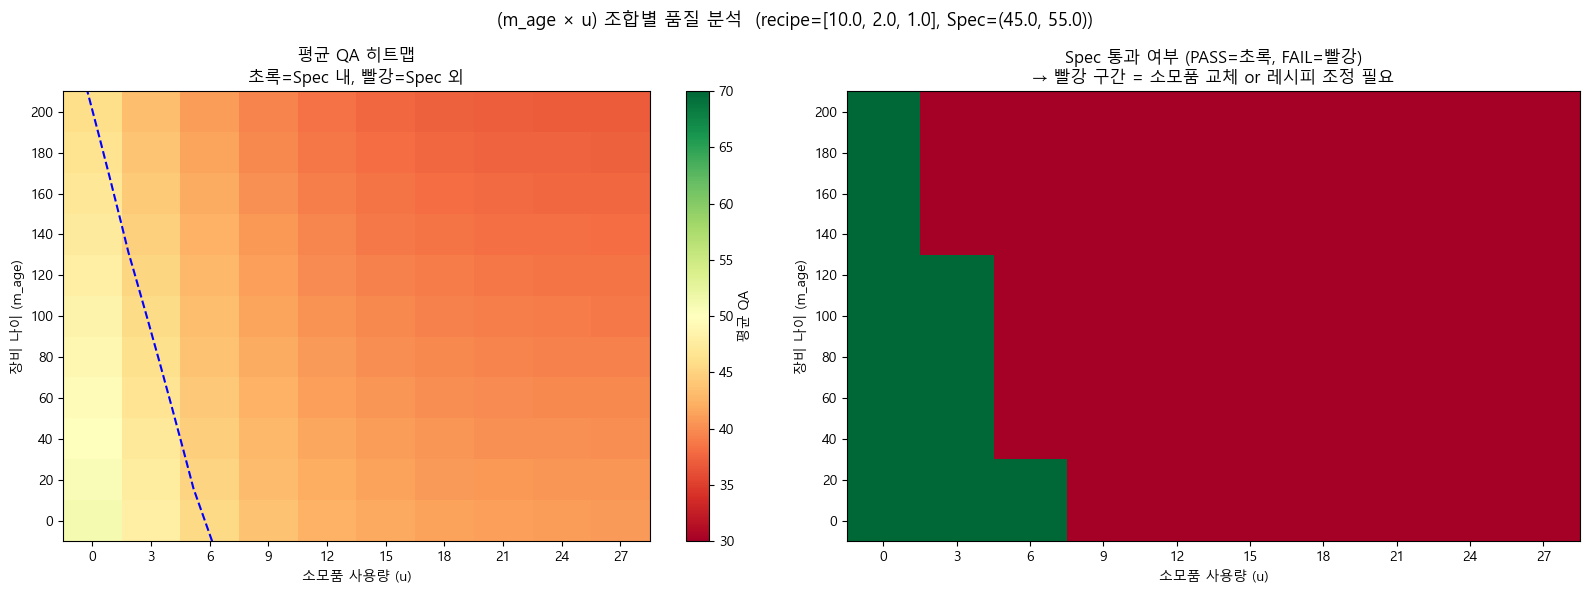

저장: results/p_a_04_joint_heatmap.png

=== 해석 ===
  전체 (m_age, u) 조합 110개 중 PASS: 20개 (18%)
  기본 교체 임계 u<10 구간에서의 PASS율: 45%
  u≥10 구간에서의 PASS율: 0%

  → should_replace_consumable()의 threshold 설정 근거로 활용 가능


In [6]:
# =============================================================
# 4. (m_age × u) 조합에 따른 평균 QA 히트맵
#    → 어떤 기계 상태에서 소모품 교체가 필요한가?
#    → 튜너의 should_replace_consumable() 설계 근거
# =============================================================

m_age_vals = np.arange(0, 201, 20)
u_vals     = np.arange(0, 30, 3)

qa_matrix = np.zeros((len(m_age_vals), len(u_vals)))
for i, m_age in enumerate(m_age_vals):
    for j, u in enumerate(u_vals):
        qa_matrix[i, j] = get_mean_qa(
            env_det, make_machine(m_age=int(m_age), u=float(u)), DEFAULT_RECIPE
        )

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(f'(m_age × u) 조합별 품질 분석  (recipe={DEFAULT_RECIPE}, Spec={SPEC_A})', fontsize=13)

# (a) 평균 QA 히트맵
vmin = SPEC_A[0] - 15
vmax = SPEC_A[1] + 15
im = axes[0].imshow(qa_matrix, aspect='auto', cmap='RdYlGn',
                     vmin=vmin, vmax=vmax, origin='lower')
plt.colorbar(im, ax=axes[0], label='평균 QA')
axes[0].set_xticks(range(len(u_vals)))
axes[0].set_xticklabels(u_vals)
axes[0].set_yticks(range(len(m_age_vals)))
axes[0].set_yticklabels(m_age_vals.astype(int))
axes[0].set_xlabel('소모품 사용량 (u)')
axes[0].set_ylabel('장비 나이 (m_age)')
axes[0].set_title('평균 QA 히트맵\n초록=Spec 내, 빨강=Spec 외')

# Spec 통과 경계 등고선
axes[0].contour(qa_matrix, levels=[SPEC_A[0], SPEC_A[1]],
                colors=['blue'], linewidths=1.5, linestyles='--',
                extent=[-0.5, len(u_vals)-0.5, -0.5, len(m_age_vals)-0.5])

# (b) Spec 통과/실패 이진 맵
pass_matrix = ((qa_matrix >= SPEC_A[0]) & (qa_matrix <= SPEC_A[1])).astype(int)
axes[1].imshow(pass_matrix, aspect='auto', cmap='RdYlGn', vmin=0, vmax=1, origin='lower')
axes[1].set_xticks(range(len(u_vals)))
axes[1].set_xticklabels(u_vals)
axes[1].set_yticks(range(len(m_age_vals)))
axes[1].set_yticklabels(m_age_vals.astype(int))
axes[1].set_xlabel('소모품 사용량 (u)')
axes[1].set_ylabel('장비 나이 (m_age)')
axes[1].set_title('Spec 통과 여부 (PASS=초록, FAIL=빨강)\n→ 빨강 구간 = 소모품 교체 or 레시피 조정 필요')

# 기본 교체 임계값 (consumable_replace_threshold=10) 표시
default_threshold = 10
if default_threshold in u_vals:
    thresh_idx = list(u_vals).index(default_threshold)
    for ax in axes:
        ax.axvline(thresh_idx, color='blue', linewidth=2.5, linestyle=':',
                   label=f'기본 교체 임계 (u={default_threshold})')
    axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig(ROOT / "results" / "p_a_04_joint_heatmap.png", dpi=100, bbox_inches='tight')
plt.show()
print("저장: results/p_a_04_joint_heatmap.png")

print(f"\n=== 해석 ===")
total = pass_matrix.size
n_pass = pass_matrix.sum()
print(f"  전체 (m_age, u) 조합 {total}개 중 PASS: {n_pass}개 ({n_pass/total:.0%})")
print(f"  기본 교체 임계 u<{default_threshold} 구간에서의 PASS율: "
      f"{pass_matrix[:, u_vals < default_threshold].mean():.0%}")
print(f"  u≥{default_threshold} 구간에서의 PASS율: "
      f"{pass_matrix[:, u_vals >= default_threshold].mean():.0%}")
print(f"\n  → should_replace_consumable()의 threshold 설정 근거로 활용 가능")

In [7]:
# =============================================================
# 5. Best-case / Worst-case 분석 + Alignment Check
#    새 튜너나 물리 모델 교체 후 검증 패턴으로 활용 가능
# =============================================================

print("=== 달성 가능한 품질 범위 분석 ===\n")

# Best-case: 새 장비(m_age=0), 새 소모품(u=0), 최대 레시피
machine_best  = make_machine(m_age=0,   u=0.0)
qa_best       = get_mean_qa(env_det, machine_best,  [50.0, 10.0, 10.0])

# Worst-case: 노후 장비(m_age=200), 낡은 소모품(u=29), 최소 레시피
machine_worst = make_machine(m_age=200, u=29.0)
qa_worst      = get_mean_qa(env_det, machine_worst, [0.0, 0.0, 0.0])

# Worst-case 분포 (stochastic)
samples_worst = sample_qa(env_stoch, machine_worst, [0.0, 0.0, 0.0], n=500)

print(f"[Best-case]   m_age=0,   u=0,  recipe=[50, 10, 10]")
print(f"  평균 QA: {qa_best:.2f}")
print(f"  Spec {SPEC_A}: {'내' if SPEC_A[0] <= qa_best <= SPEC_A[1] else '외'}")

print(f"\n[Worst-case]  m_age=200, u=29, recipe=[0, 0, 0]")
print(f"  평균 QA: {qa_worst:.2f}")
print(f"  Spec {SPEC_A}: {'내' if SPEC_A[0] <= qa_worst <= SPEC_A[1] else '외'}")
print(f"  99.7% 범위: [{np.percentile(samples_worst, 0.15):.2f}, {np.percentile(samples_worst, 99.85):.2f}]")

print(f"\n  → 달성 가능한 QA 범위: [{qa_worst:.1f}, {qa_best:.1f}]")
print(f"     Spec A {SPEC_A} 대비 {'충분한 overlap 존재' if qa_best > SPEC_A[0] and qa_worst < SPEC_A[1] else '범위 재검토 필요'}")

# Alignment Check: s1 스윕으로 PASS/FAIL 전환 구간 확인
print(f"\n=== Alignment Check: s1 스윕 (m_age=0, u=0 고정) ===")
print(f"  (물리 모델 교체 후 이 패턴으로 spec 정합성 검증)")
print(f"\n  {'s1':>6} | {'mean_qa':>9} | {'결과':>6}")
print("  " + "-" * 28)
machine_check = make_machine(m_age=0, u=0.0)
for s1 in [0.0, 5.0, 10.0, 15.0, 20.0, 30.0, 50.0]:
    qa = get_mean_qa(env_det, machine_check, [s1, 2.0, 1.0])
    result = "PASS" if SPEC_A[0] <= qa <= SPEC_A[1] else "FAIL"
    marker = " ←" if result == "PASS" else ""
    print(f"  {s1:>6.1f} | {qa:>9.2f} | {result:>6}{marker}")

print(f"\n  → 모든 레시피에서 PASS 또는 FAIL만 나오면 spec 범위 재조정 필요")

=== 달성 가능한 품질 범위 분석 ===

[Best-case]   m_age=0,   u=0,  recipe=[50, 10, 10]
  평균 QA: 80.00
  Spec (45.0, 55.0): 외

[Worst-case]  m_age=200, u=29, recipe=[0, 0, 0]
  평균 QA: 32.85
  Spec (45.0, 55.0): 외
  99.7% 범위: [28.98, 37.07]

  → 달성 가능한 QA 범위: [32.8, 80.0]
     Spec A (45.0, 55.0) 대비 충분한 overlap 존재

=== Alignment Check: s1 스윕 (m_age=0, u=0 고정) ===
  (물리 모델 교체 후 이 패턴으로 spec 정합성 검증)

      s1 |   mean_qa |     결과
  ----------------------------
     0.0 |     45.80 |   PASS ←
     5.0 |     48.40 |   PASS ←
    10.0 |     51.00 |   PASS ←
    15.0 |     53.60 |   PASS ←
    20.0 |     56.20 |   FAIL
    30.0 |     61.40 |   FAIL
    50.0 |     71.80 |   FAIL

  → 모든 레시피에서 PASS 또는 FAIL만 나오면 spec 범위 재조정 필요


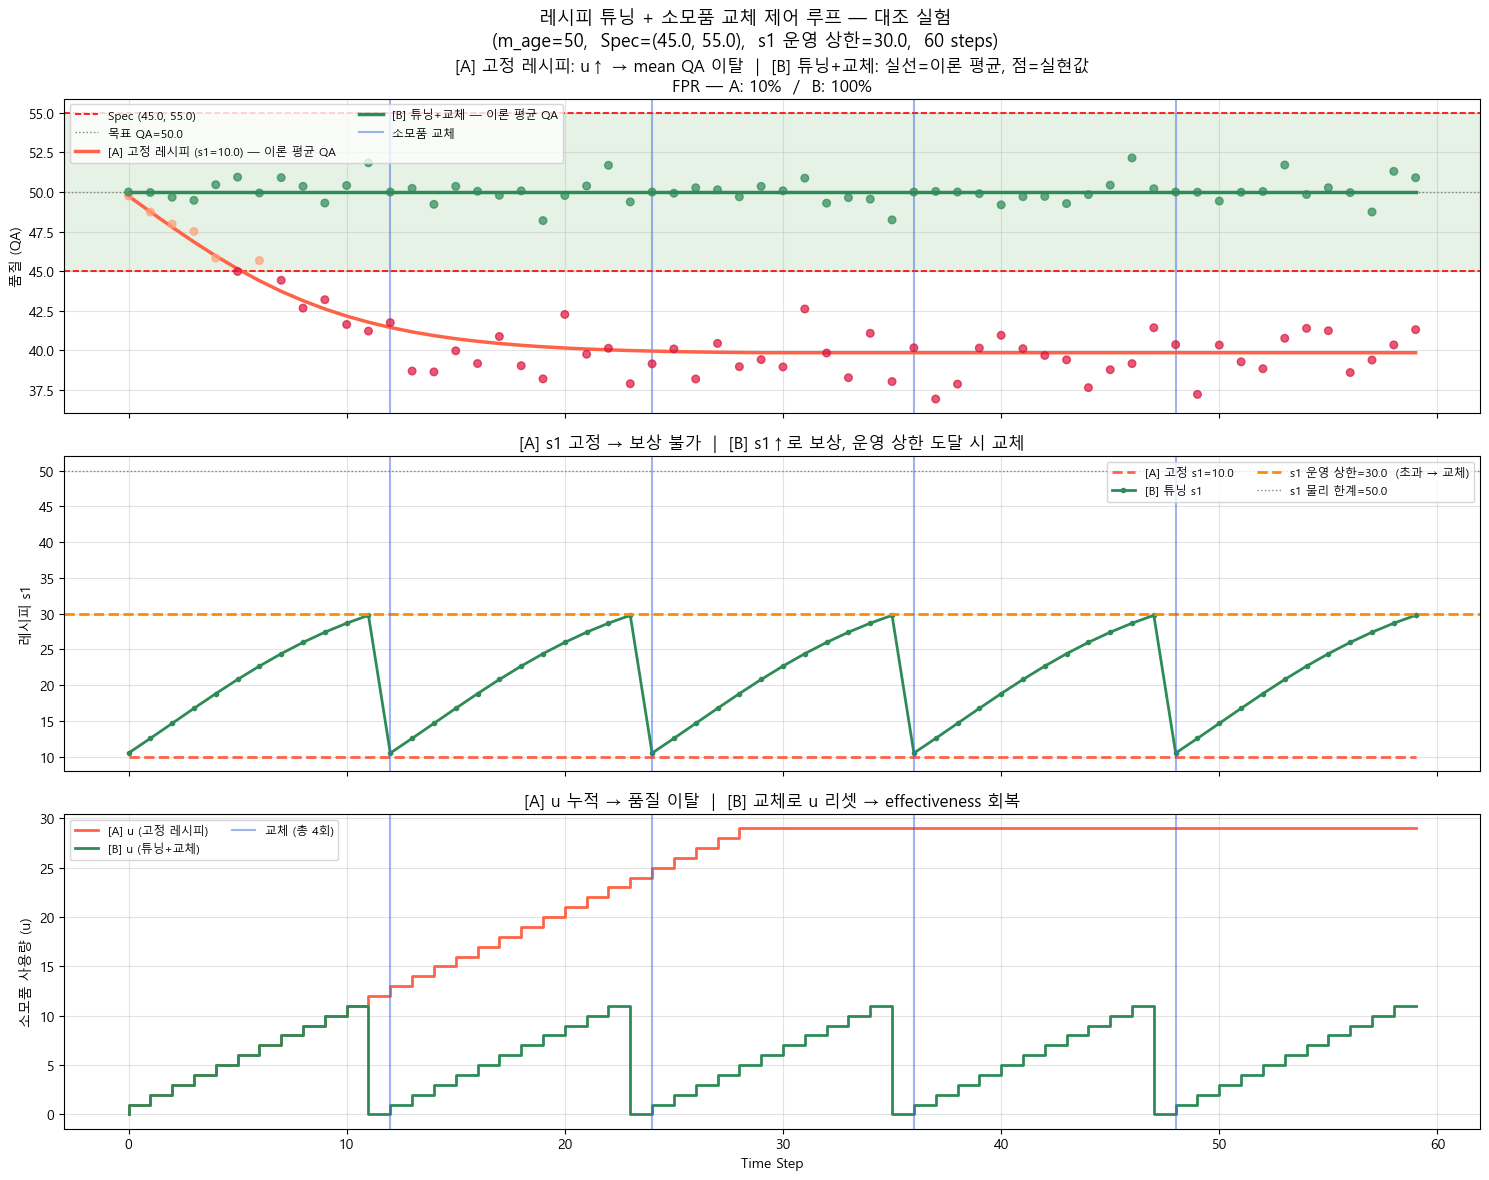

저장: results/p_a_05_tuning_simulation.png

  시나리오          FPR     Spec 이탈   min mean_QA
  [A] 고정 레시피   10%      54회       39.9
  [B] 튜닝+교체     100%       0회       50.0

  튜너의 역할:
  → 레시피 튜닝: s1을 10.5 ~ 29.8로 조정해 mean QA를 목표(50.0)에 유지
  → 소모품 교체: 4회 교체 (step [12, 24, 36, 48]) → u 리셋으로 effectiveness 회복
  → 결과: Spec 이탈 54회 → 0회로 감소


In [13]:
# =============================================================
# 6. 제어 루프 시뮬레이션 — 비교 실험
#    [Sim A] 고정 레시피 (튜닝 없음) — u 증가에 따라 품질이 spec 아래로 이탈
#    [Sim B] 레시피 튜닝 + 소모품 교체  — spec 내 품질 유지
#
#  목적: 튜너가 하는 일을 대조 실험으로 시각화한다.
#    → 튜닝 없이 u만 증가하면 mean QA가 spec 이탈
#    → 튜너는 s1↑로 보상하다가 운영 상한 도달 시 소모품 교체로 effectiveness 회복
# =============================================================

np.random.seed(42)

N_STEPS   = 60
M_AGE     = 50
S2, S3    = 2.0, 1.0
S1_FIXED  = 10.0          # Sim A: 고정 레시피 (초기 최적값, 이후 미조정)
TARGET_QA = (SPEC_A[0] + SPEC_A[1]) / 2
S1_MIN, S1_MAX = 0.0, 50.0
S1_OP_MAX = 30.0           # 운영 상한: 초과 시 소모품 교체 트리거

def compute_s1_raw(m_age, u, target_qa, s2, s3):
    """target_qa 달성에 필요한 s1 역산 (클리핑 없음)."""
    w1, w12, b = env_det._get_physical_model_params(m_age)
    eff = 1 - BETA * np.tanh(BETA_K * u)
    if eff < 1e-6: return float('inf')
    denom = w1 + w12 * s2
    if abs(denom) < 1e-9: return float('inf')
    return ((target_qa / eff) - (W2_BASE * s2 + W3_BASE * s3 + b)) / denom

def get_mean_qa_at(m_age, u, recipe):
    """Deterministic 모드 평균 QA (노이즈 없는 이론값)."""
    return get_mean_qa(env_det, make_machine(m_age=m_age, u=u), recipe)

# ── Sim A: 고정 레시피 ────────────────────────────────────────
u_a, hist_a = 0.0, []
for step in range(N_STEPS):
    mean_qa_a = get_mean_qa_at(M_AGE, u_a, [S1_FIXED, S2, S3])
    qa_a = sample_qa(env_stoch, make_machine(M_AGE, u_a), [S1_FIXED, S2, S3], n=1)[0]
    hist_a.append({'step': step, 'u': u_a, 's1': S1_FIXED,
                   'mean_qa': mean_qa_a, 'qa': qa_a,
                   'passed': SPEC_A[0] <= qa_a <= SPEC_A[1]})
    u_a = min(u_a + 1.0, 29.0)

# ── Sim B: 레시피 튜닝 + 소모품 교체 ─────────────────────────
u_b, hist_b = 0.0, []
for step in range(N_STEPS):
    s1_raw = compute_s1_raw(M_AGE, u_b, TARGET_QA, S2, S3)
    replaced = False
    if s1_raw > S1_OP_MAX:
        u_b = 0.0; replaced = True
        s1_raw = compute_s1_raw(M_AGE, u_b, TARGET_QA, S2, S3)
    s1_opt = float(np.clip(s1_raw, S1_MIN, S1_MAX))
    mean_qa_b = get_mean_qa_at(M_AGE, u_b, [s1_opt, S2, S3])
    qa_b = sample_qa(env_stoch, make_machine(M_AGE, u_b), [s1_opt, S2, S3], n=1)[0]
    hist_b.append({'step': step, 'u': u_b, 's1': s1_opt,
                   'mean_qa': mean_qa_b, 'qa': qa_b,
                   'passed': SPEC_A[0] <= qa_b <= SPEC_A[1], 'replaced': replaced})
    u_b = min(u_b + 1.0, 29.0)

df_a = pd.DataFrame(hist_a)
df_b = pd.DataFrame(hist_b)
repl_steps = df_b[df_b['replaced']]['step'].tolist()

# ── 시각화 ───────────────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(15, 12), sharex=True)
fig.suptitle(
    f'레시피 튜닝 + 소모품 교체 제어 루프 — 대조 실험\n'
    f'(m_age={M_AGE},  Spec={SPEC_A},  s1 운영 상한={S1_OP_MAX},  {N_STEPS} steps)',
    fontsize=13
)
steps = df_a['step']
repl_color = 'royalblue'

# ── 패널 1: QA 비교 ──────────────────────────────────────────
ax = axes[0]
ax.axhspan(SPEC_A[0], SPEC_A[1], alpha=0.10, color='green', zorder=0)
ax.axhline(SPEC_A[0], color='red', linestyle='--', linewidth=1.2)
ax.axhline(SPEC_A[1], color='red', linestyle='--', linewidth=1.2, label=f'Spec {SPEC_A}')
ax.axhline(TARGET_QA, color='gray', linestyle=':', linewidth=1, label=f'목표 QA={TARGET_QA}')

# Sim A
ax.plot(steps, df_a['mean_qa'], color='tomato', linewidth=2.5,
        label=f'[A] 고정 레시피 (s1={S1_FIXED}) — 이론 평균 QA', zorder=3)
ax.scatter(steps, df_a['qa'],
           c=['crimson' if not p else 'lightsalmon' for p in df_a['passed']],
           s=30, alpha=0.7, zorder=4)

# Sim B
ax.plot(steps, df_b['mean_qa'], color='seagreen', linewidth=2.5,
        label='[B] 튜닝+교체 — 이론 평균 QA', zorder=3)
ax.scatter(steps, df_b['qa'],
           c=['seagreen' if p else 'red' for p in df_b['passed']],
           s=30, alpha=0.7, zorder=4)

for i, r in enumerate(repl_steps):
    ax.axvline(r, color=repl_color, linewidth=1.5, alpha=0.5,
               label='소모품 교체' if i == 0 else '')

ax.set_ylabel('품질 (QA)')
ax.set_title(
    f'[A] 고정 레시피: u↑ → mean QA 이탈  |  [B] 튜닝+교체: 실선=이론 평균, 점=실현값\n'
    f'FPR — A: {df_a["passed"].mean():.0%}  /  B: {df_b["passed"].mean():.0%}'
)
ax.legend(fontsize=8.5, ncol=2)
ax.grid(True, alpha=0.35)

# ── 패널 2: s1 비교 ──────────────────────────────────────────
ax = axes[1]
ax.plot(steps, df_a['s1'], color='tomato', linewidth=2, linestyle='--',
        label=f'[A] 고정 s1={S1_FIXED}')
ax.plot(steps, df_b['s1'], color='seagreen', linewidth=2, marker='o', markersize=3,
        label='[B] 튜닝 s1')
ax.axhline(S1_OP_MAX, color='darkorange', linestyle='--', linewidth=2,
           label=f's1 운영 상한={S1_OP_MAX}  (초과 → 교체)')
ax.axhline(S1_MAX, color='gray', linestyle=':', linewidth=1,
           label=f's1 물리 한계={S1_MAX}')
for r in repl_steps:
    ax.axvline(r, color=repl_color, linewidth=1.5, alpha=0.5)
ax.set_ylabel('레시피 s1')
ax.set_title('[A] s1 고정 → 보상 불가  |  [B] s1↑로 보상, 운영 상한 도달 시 교체')
ax.legend(fontsize=8.5, ncol=2)
ax.grid(True, alpha=0.35)

# ── 패널 3: u 비교 ───────────────────────────────────────────
ax = axes[2]
ax.step(steps, df_a['u'], color='tomato', linewidth=2, where='pre',
        label='[A] u (고정 레시피)')
ax.step(steps, df_b['u'], color='seagreen', linewidth=2, where='pre',
        label='[B] u (튜닝+교체)')
for i, r in enumerate(repl_steps):
    ax.axvline(r, color=repl_color, linewidth=1.5, alpha=0.5,
               label=f'교체 (총 {len(repl_steps)}회)' if i == 0 else '')
ax.set_xlabel('Time Step')
ax.set_ylabel('소모품 사용량 (u)')
ax.set_title('[A] u 누적 → 품질 이탈  |  [B] 교체로 u 리셋 → effectiveness 회복')
ax.legend(fontsize=8.5, ncol=2)
ax.grid(True, alpha=0.35)

plt.tight_layout()
plt.savefig(ROOT / "results" / "p_a_05_tuning_simulation.png", dpi=100, bbox_inches='tight')
plt.show()
print("저장: results/p_a_05_tuning_simulation.png")

# ── 요약 ─────────────────────────────────────────────────────
spec_fail_a = (~df_a['passed']).sum()
spec_fail_b = (~df_b['passed']).sum()

print(f"\n{'='*55}")
print(f"  시나리오          FPR     Spec 이탈   min mean_QA")
print(f"  [A] 고정 레시피   {df_a['passed'].mean():.0%}     {spec_fail_a:3d}회       {df_a['mean_qa'].min():.1f}")
print(f"  [B] 튜닝+교체     {df_b['passed'].mean():.0%}     {spec_fail_b:3d}회       {df_b['mean_qa'].min():.1f}")
print(f"{'='*55}")
print(f"\n  튜너의 역할:")
print(f"  → 레시피 튜닝: s1을 {df_b['s1'].min():.1f} ~ {df_b['s1'].max():.1f}로 조정해 mean QA를 목표({TARGET_QA})에 유지")
print(f"  → 소모품 교체: {len(repl_steps)}회 교체 (step {repl_steps}) → u 리셋으로 effectiveness 회복")
print(f"  → 결과: Spec 이탈 {spec_fail_a}회 → {spec_fail_b}회로 감소")
